In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/loan-approval-prediction-dataset/loan_approval_dataset.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize']=[14,5]

In [3]:
df=pd.read_csv('/kaggle/input/loan-approval-prediction-dataset/loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.shape

(4269, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [6]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [7]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [8]:
cols = []
for i in df.columns:
    if i[0]==" ":
        cols.append(i[1:])
    else:
        cols.append(i)

In [9]:
df.columns = cols

In [10]:
df=df.drop('loan_id',axis=1)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [11]:
len(df.columns)

12

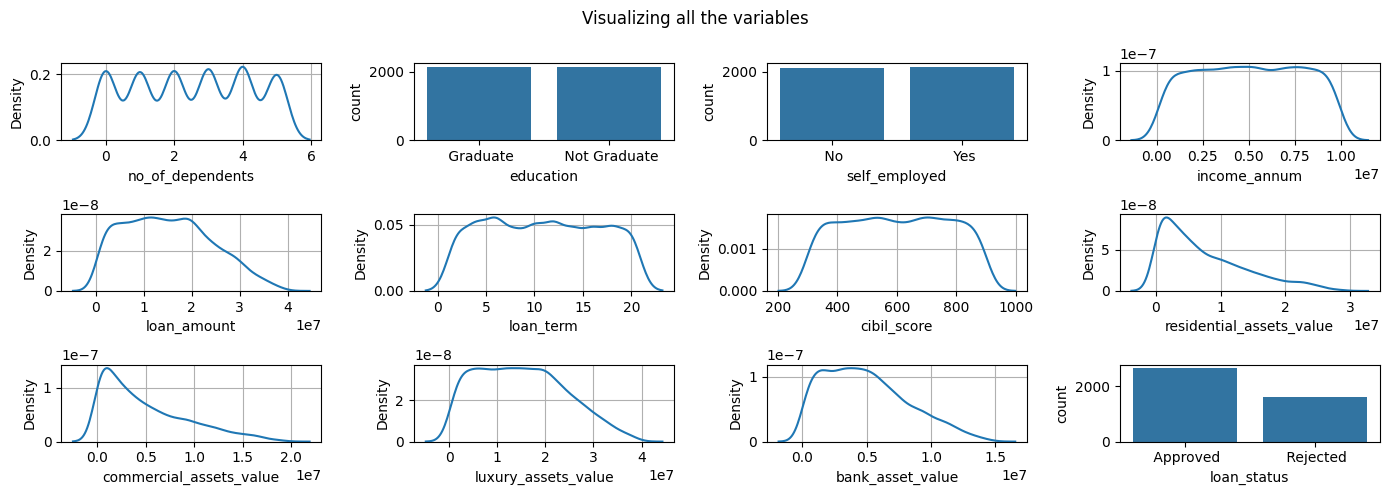

In [12]:
r=3
c=4
it=1
for i in df.columns:
    plt.suptitle("Visualizing all the variables")
    plt.subplot(r,c,it)
    if df[i].dtypes=="object":
        sns.countplot(x=df[i])
    else:
        sns.kdeplot(x=df[i])
        plt.grid()
    it+=1
plt.tight_layout()
plt.show()

In [13]:
df.select_dtypes(include="object").columns

Index(['education', 'self_employed', 'loan_status'], dtype='object')

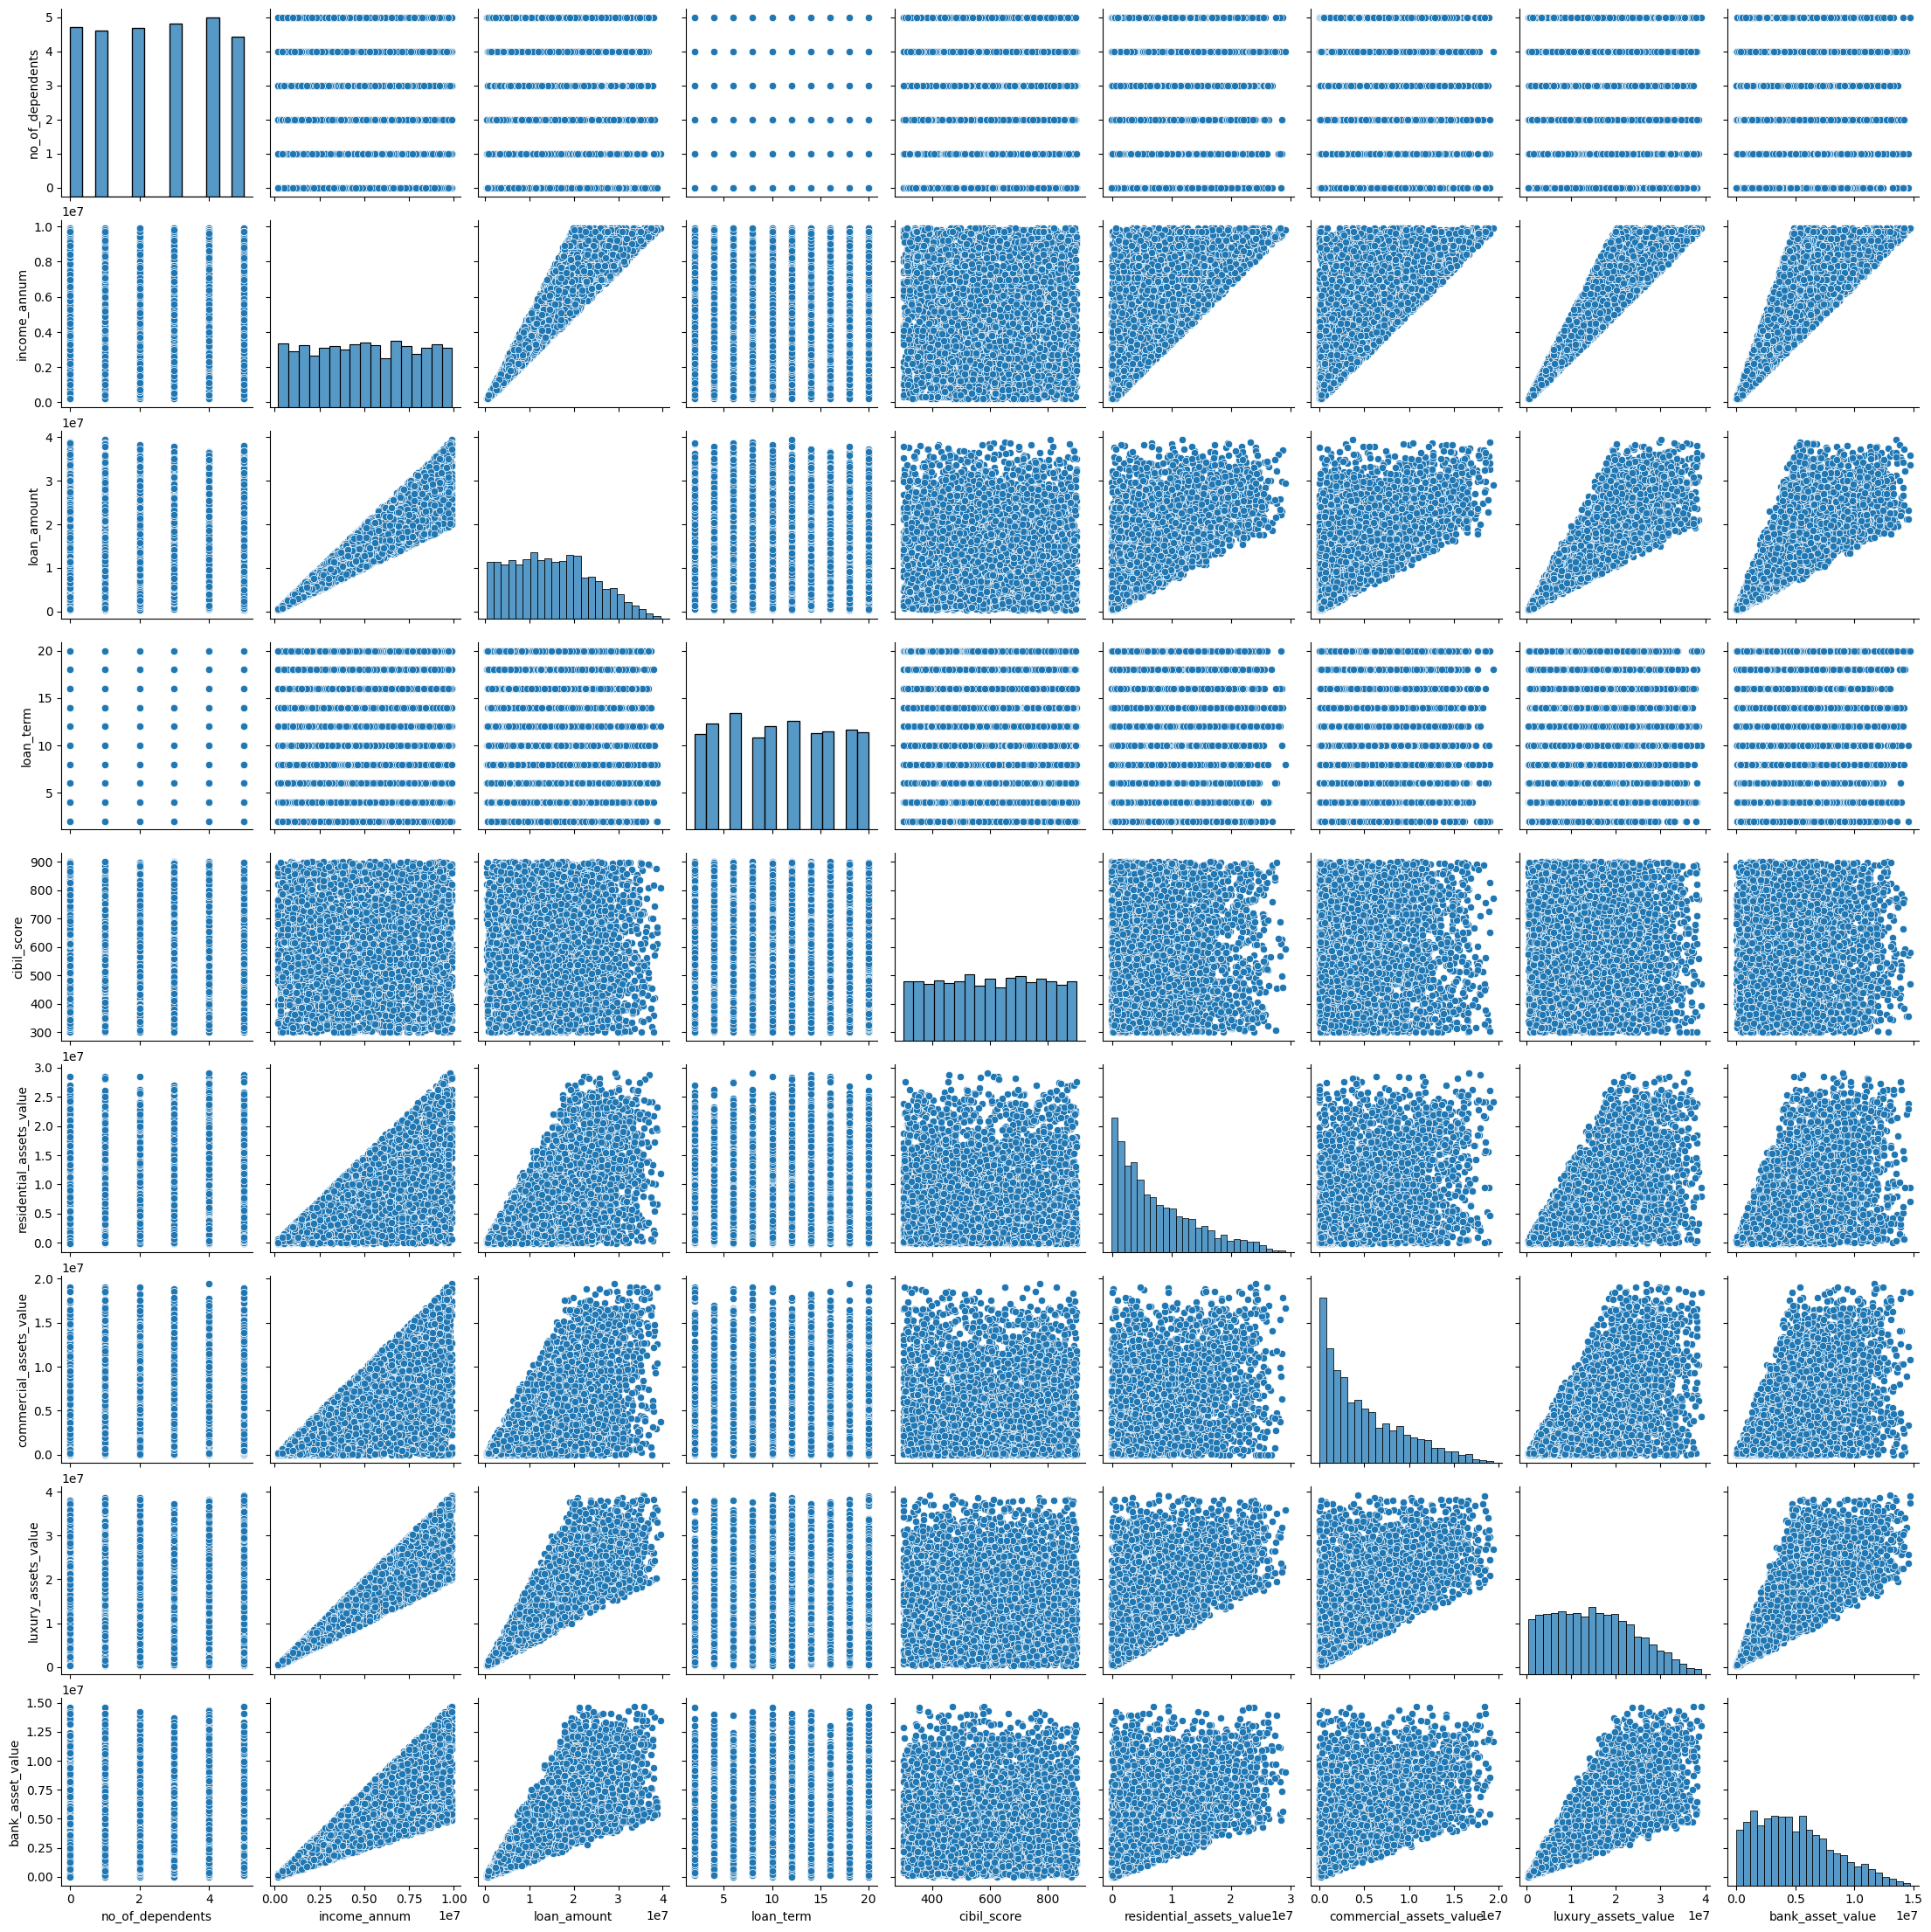

In [14]:
sns.pairplot(df.select_dtypes(exclude="object"))
plt.show()

In [15]:
df['education'] = df['education'].map({' Graduate':1,' Not Graduate':0})
df['self_employed'] = df['self_employed'].map({' No':0,' Yes':1})
df['loan_status'] = df['loan_status'].map({' Approved':1,' Rejected':0})

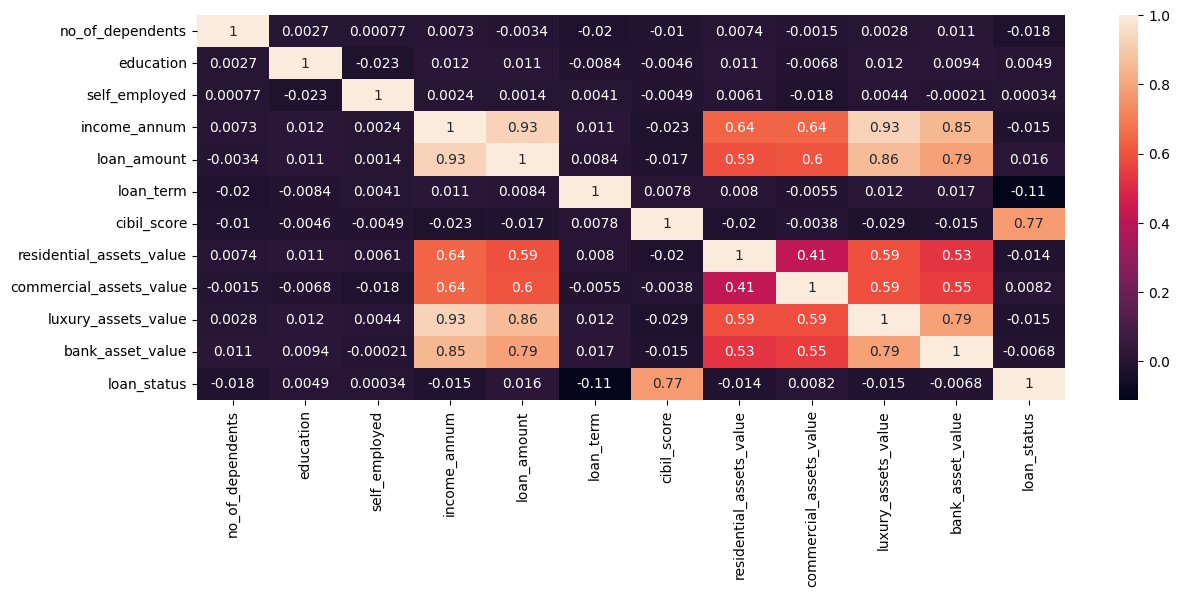

In [16]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [17]:
# full model

<Axes: >

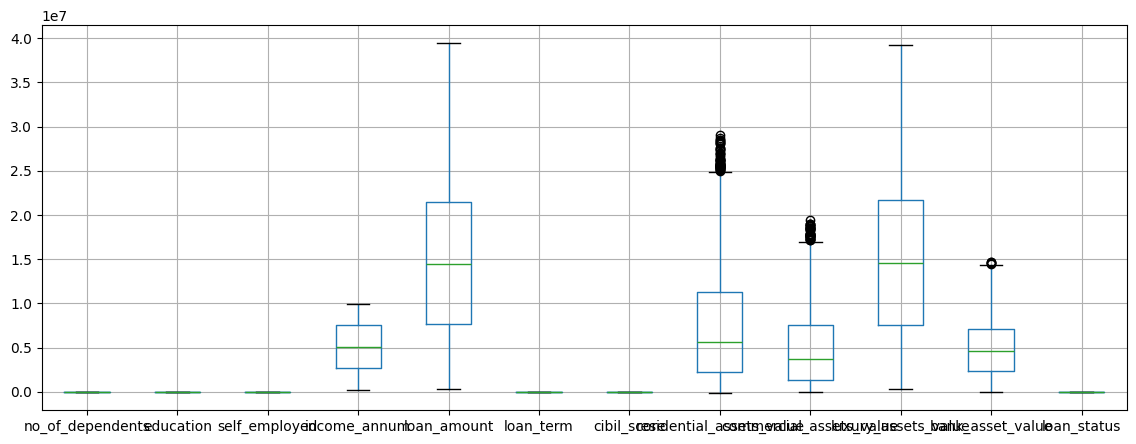

In [18]:
df.boxplot()

In [19]:
cols_to_remove_outliers = df.columns
 
for i in cols_to_remove_outliers:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    ll=q1-(1.5*iqr)
    ul=q3+(1.5*iqr)
    for k in df[i]:
        if k<ll:
            df[i] = df[i].replace(k,ll)
        if k>ul:
            df[i] = df[i].replace(k,ul)

<Axes: >

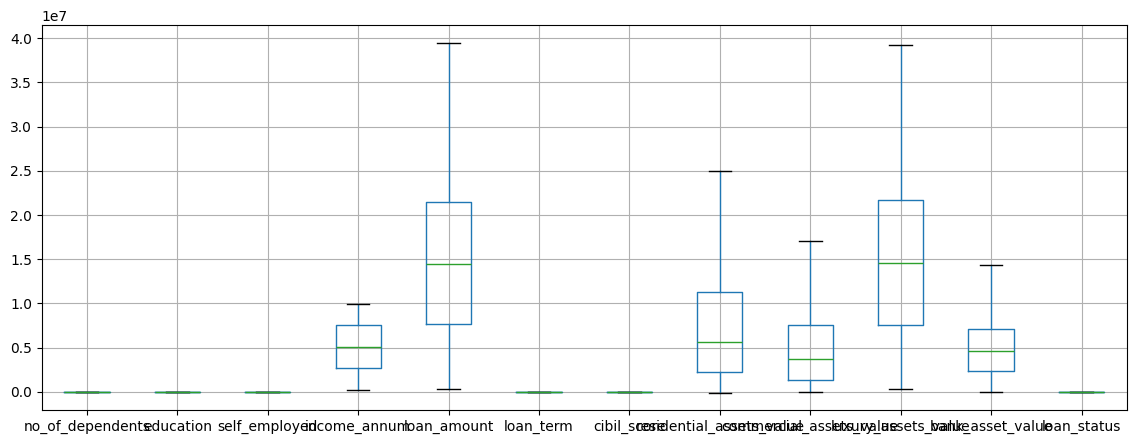

In [20]:
df.boxplot()

In [21]:
df_1 = df.copy()
df_1.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17050000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
xtrain,xtest,ytrain,ytest = train_test_split(df_1.drop('loan_status',axis=1),df_1['loan_status'],test_size=0.30,random_state=42)

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [25]:
rf = RandomForestClassifier()

In [26]:
rf.fit(xtrain,ytrain)

RandomForestClassifier()

In [27]:
print("The accuracy score for train set is",accuracy_score(ytrain,rf.predict(xtrain)))
print("The precision score for train set is",precision_score(ytrain,rf.predict(xtrain)))
print("The recall score for train set is",recall_score(ytrain,rf.predict(xtrain)))
print("The f1 score for train set is",f1_score(ytrain,rf.predict(xtrain)))
print("")
print("The accuracy score for test set is",accuracy_score(ytest,rf.predict(xtest)))
print("The precision score for test set is",precision_score(ytest,rf.predict(xtest)))
print("The recall score for test set is",recall_score(ytest,rf.predict(xtest)))
print("The f1 score for test set is",f1_score(ytest,rf.predict(xtest)))

The accuracy score for train set is 1.0
The precision score for train set is 1.0
The recall score for train set is 1.0
The f1 score for train set is 1.0

The accuracy score for test set is 0.9789227166276346
The precision score for test set is 0.9827373612823674
The recall score for test set is 0.9839506172839506
The f1 score for test set is 0.9833436150524367


In [28]:
rf.feature_importances_

array([0.00807259, 0.00256032, 0.00282509, 0.01714744, 0.02760144,
       0.05495218, 0.81877879, 0.0178653 , 0.0159484 , 0.01851568,
       0.01573278])

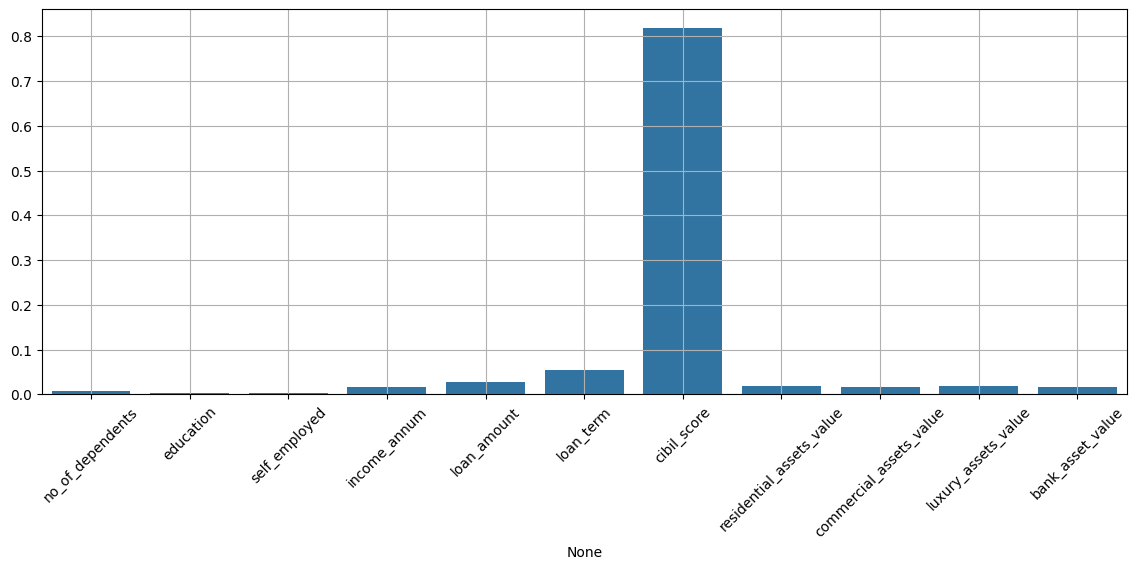

In [29]:
sns.barplot(x=xtrain.columns,y=rf.feature_importances_)
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [30]:
# clustering

In [31]:
from sklearn.preprocessing import MinMaxScaler

In [32]:
mmax = MinMaxScaler()

In [33]:
df = pd.DataFrame(mmax.fit_transform(df),columns=df.columns)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,0.4,1.0,0.0,0.969072,0.755102,0.555556,0.796667,0.099800,1.000000,0.575835,0.559441,1.0
1,0.0,0.0,1.0,0.402062,0.303571,0.333333,0.195000,0.111776,0.129032,0.218509,0.230769,0.0
2,0.6,1.0,0.0,0.917526,0.750000,1.000000,0.343333,0.287425,0.263930,0.848329,0.895105,0.0
3,0.6,1.0,0.0,0.824742,0.775510,0.333333,0.278333,0.730539,0.193548,0.591260,0.552448,0.0
4,1.0,0.0,1.0,0.989691,0.609694,1.000000,0.136667,0.499002,0.480938,0.748072,0.349650,0.0


In [34]:
from sklearn.cluster import KMeans

In [35]:
max_limit = 7

wcss = []

for k in range(2,max_limit):
    kmeans = KMeans(n_clusters=k,random_state=42)
    model = kmeans.fit(df)
    wcss.append(model.inertia_)

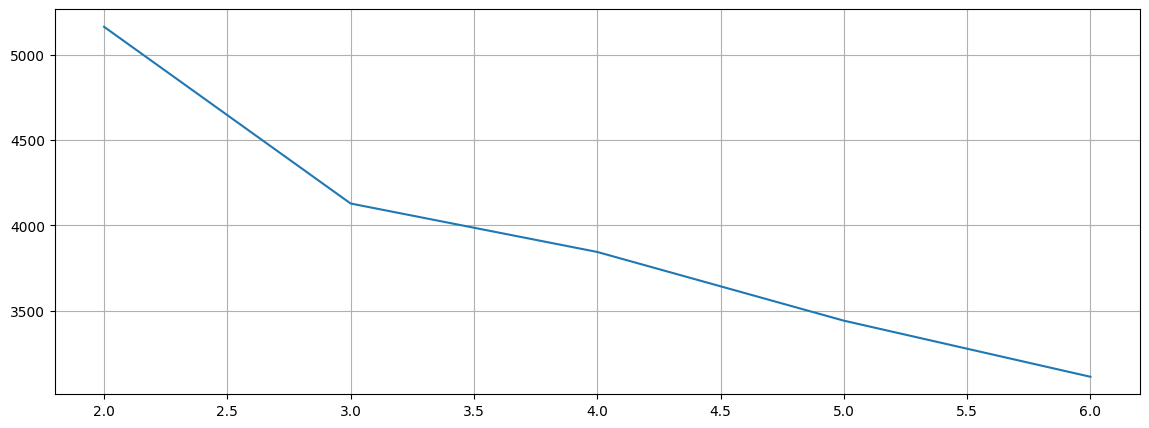

In [36]:
plt.plot(range(2,max_limit),wcss)
plt.grid()
plt.show()

In [37]:
!pip install kneed

In [38]:
from kneed import KneeLocator

In [39]:
kneedle = KneeLocator(range(2,max_limit), wcss, curve="convex", direction="decreasing") 
print("Optimal k:", kneedle.knee)

Optimal k: 3


In [40]:
kmeans = KMeans(n_clusters=k,random_state=42)
model = kmeans.fit(df)

In [41]:
model.labels_

array([3, 0, 4, ..., 4, 5, 3], dtype=int32)

In [42]:
df['labels'] = pd.Series(model.labels_)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,labels
0,0.4,1.0,0.0,0.969072,0.755102,0.555556,0.796667,0.099800,1.000000,0.575835,0.559441,1.0,3
1,0.0,0.0,1.0,0.402062,0.303571,0.333333,0.195000,0.111776,0.129032,0.218509,0.230769,0.0,0
2,0.6,1.0,0.0,0.917526,0.750000,1.000000,0.343333,0.287425,0.263930,0.848329,0.895105,0.0,4
3,0.6,1.0,0.0,0.824742,0.775510,0.333333,0.278333,0.730539,0.193548,0.591260,0.552448,0.0,4
4,1.0,0.0,1.0,0.989691,0.609694,1.000000,0.136667,0.499002,0.480938,0.748072,0.349650,0.0,0


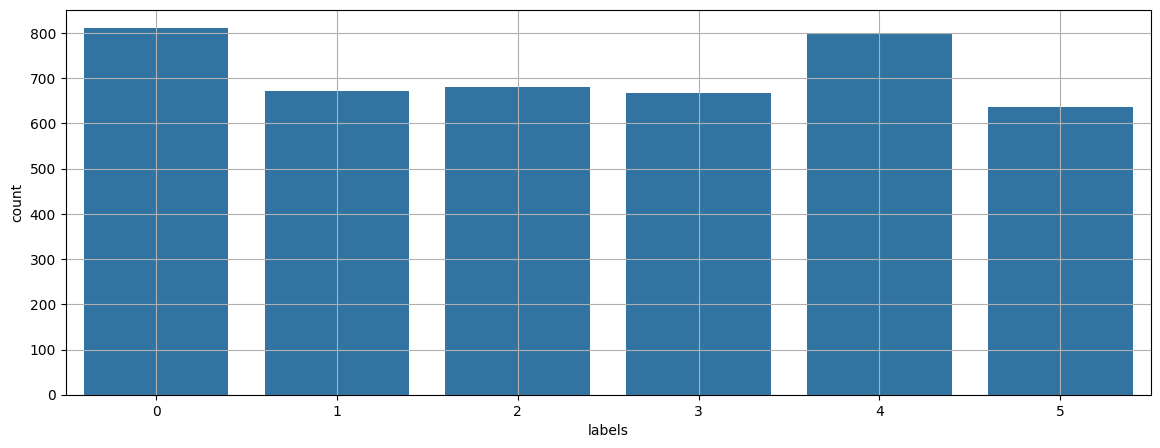

In [43]:
sns.countplot(x=df['labels'])
plt.grid()